# `sub-01` network states and depicted emotion in *Friends* S1E1

This notebook fits one labels-blind HMM per cortical network on other episodes, decodes S1E1 once, and descriptively compares held-out state probabilities with the supplied valence/arousal labels. It does not test the participant's felt emotion or support population-level inference.

## Setup

In [1]:
from pathlib import Path
import sys
import warnings

import h5py
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM
from joblib import Parallel, delayed, parallel_config
from nilearn import datasets, image, plotting
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

working_path = Path.cwd().resolve()
PROJECT_ROOT = next((
    path for path in (working_path, *working_path.parents)
    if (path / 'pyproject.toml').is_file()
), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError(f'Could not find the project root from {working_path}')
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from preprocessing.brainstates.data import SegmentKey, discover_fmri_segments
from preprocessing.brainstates.networks import network_indices

SUBJECT = 'sub-01'
NETWORKS = ('VIS', 'SMN', 'DAN', 'VAN', 'LIM', 'FPC', 'DN')
TARGET_SEGMENTS = (SegmentKey(1, 1, 'a'), SegmentKey(1, 1, 'b'))
K_VALUES = tuple(range(1, 7))
SEEDS = tuple(range(2025, 2030))
N_JOBS = 20
N_COMPONENTS = 10
HMM_N_ITER = 500
HMM_TOL = 1e-3
MIN_STATE_OCCUPANCY = 0.01
PRIMARY_LAG = 3
LAG_VALUES = tuple(range(7))

FMRI_PATH = (
    PROJECT_ROOT / 'data/algonauts_2025.competitors/fmri' / SUBJECT / 'func'
    / f'{SUBJECT}_task-friends_space-MNI152NLin2009cAsym_'
      'atlas-Schaefer18_parcel-1000Par7Net_desc-s123456_bold.h5'
)
LABEL_PATHS = {
    segment: PROJECT_ROOT / 'data/manual-data' / f'friends_{segment.task}_my_emotion.tsv'
    for segment in TARGET_SEGMENTS
}
RESULT_ROOT = PROJECT_ROOT / 'outputs/sub01_s01e01_network_emotion'
FIGURE_ROOT = RESULT_ROOT / 'figures'
MODEL_ROOT = RESULT_ROOT / 'models'
for path in (RESULT_ROOT, FIGURE_ROOT, MODEL_ROOT):
    path.mkdir(parents=True, exist_ok=True)

print('Project:', PROJECT_ROOT)
print('Subject:', SUBJECT)
print('Output:', RESULT_ROOT)

Project: /home/ducvu/project/Neuromatch-Algonauts2026
Subject: sub-01
Output: /home/ducvu/project/Neuromatch-Algonauts2026/outputs/sub01_s01e01_network_emotion


## Brain-map helpers

Direct maps show mean held-out parcel BOLD differences. HMM-implied maps back-project each network's state means through PCA and scaling, then weight those parcel patterns by the signed state-posterior contrast. Both are descriptive parcel-level maps.

In [ ]:
def condition_mean_difference(values, labels, first, second):
    """Return first-condition mean minus second-condition mean."""
    labels = np.asarray(labels)
    first_values = values[labels == first]
    second_values = values[labels == second]
    if not len(first_values) or not len(second_values):
        raise ValueError(f'Unsupported contrast: {first} versus {second}')
    return first_values.mean(axis=0) - second_values.mean(axis=0)


def posterior_weighted_parcel_contrast(
    state_parcel_means, gamma, labels, first, second,
):
    posterior_difference = condition_mean_difference(
        gamma, labels, first, second
    )
    return posterior_difference @ state_parcel_means


def parcel_values_to_volume(parcel_values, atlas_labels):
    """Paint a 1-D parcel vector onto integer atlas labels."""
    parcel_values = np.asarray(parcel_values, dtype=float)
    atlas_labels = np.asarray(atlas_labels, dtype=int)
    if parcel_values.ndim != 1:
        raise ValueError('parcel_values must be one-dimensional')
    if atlas_labels.min() < 0 or atlas_labels.max() > len(parcel_values):
        raise ValueError('atlas labels fall outside the parcel vector')
    return np.concatenate(([0.0], parcel_values))[atlas_labels]

## Discover data and audit the held-out split

In [2]:
if not FMRI_PATH.is_file():
    raise FileNotFoundError(FMRI_PATH)
missing_labels = [str(path) for path in LABEL_PATHS.values() if not path.is_file()]
if missing_labels:
    raise FileNotFoundError(f'Missing label files: {missing_labels}')

discovered = discover_fmri_segments(FMRI_PATH)
all_segments = tuple(sorted(discovered))
train_segments = tuple(
    segment for segment in all_segments
    if segment.season <= 4 and segment not in TARGET_SEGMENTS
)
validation_segments = tuple(
    segment for segment in all_segments if segment.season == 5
)
final_train_segments = tuple(
    segment for segment in all_segments
    if segment.season <= 5 and segment not in TARGET_SEGMENTS
)

expected_counts = (292, 192, 48, 240)
actual_counts = (
    len(all_segments), len(train_segments),
    len(validation_segments), len(final_train_segments),
)
if actual_counts != expected_counts:
    raise ValueError(f'Unexpected segment counts: {actual_counts}, expected {expected_counts}')
if any(segment in train_segments or segment in final_train_segments for segment in TARGET_SEGMENTS):
    raise ValueError('S1E1 leaked into model-fitting data')

with h5py.File(FMRI_PATH, 'r') as handle:
    data_audit = pd.DataFrame([
        {
            'subject': SUBJECT,
            'segment': segment.task,
            'season': segment.season,
            'episode': segment.episode,
            'split': segment.split,
            'n_tr': handle[discovered[segment]].shape[0],
        }
        for segment in all_segments
    ])
data_audit.to_csv(RESULT_ROOT / 'data_audit.csv', index=False)
print('All / train / validation / final-train:', actual_counts)
data_audit.query("season == 1 and episode == 1")

All / train / validation / final-train: (292, 192, 48, 240)


,subject,segment,season,episode,split,n_tr
0,sub-01,s01e01a,1,1,a,592
1,sub-01,s01e01b,1,1,b,592


In [3]:
def shift_labels(labels, lag):
    """Shift labels forward without crossing the current segment."""
    if lag < 0:
        raise ValueError('lag must be non-negative')
    shifted = labels.copy()
    shifted[['valence', 'arousal']] = shifted[['valence', 'arousal']].shift(lag)
    return shifted

In [4]:
labels_by_segment = {}
target_lengths = {}
with h5py.File(FMRI_PATH, 'r') as handle:
    for segment, path in LABEL_PATHS.items():
        labels = pd.read_csv(path, sep='\t', na_values=['NA'])[['valence', 'arousal']]
        target_length = handle[discovered[segment]].shape[0]
        if len(labels) > target_length:
            raise ValueError(f'{segment.task}: {len(labels)} labels for {target_length} TRs')
        labels_by_segment[segment] = labels
        target_lengths[segment] = target_length

label_audit_rows = []
for lag in (0, PRIMARY_LAG):
    shifted_parts = [shift_labels(labels_by_segment[segment], lag) for segment in TARGET_SEGMENTS]
    for label in ('valence', 'arousal'):
        values = pd.concat([part[label] for part in shifted_parts], ignore_index=True)
        for value, count in values.value_counts(dropna=False).items():
            label_audit_rows.append({
                'lag_tr': lag, 'label': label,
                'value': value, 'n_tr': int(count),
            })
label_audit = pd.DataFrame(label_audit_rows)
label_audit.to_csv(RESULT_ROOT / 'label_audit.csv', index=False)
print('Target fMRI lengths:', {key.task: value for key, value in target_lengths.items()})
print('Target label lengths:', {key.task: len(value) for key, value in labels_by_segment.items()})
label_audit.query('lag_tr == @PRIMARY_LAG').sort_values(['label', 'value'])

Target fMRI lengths: {'s01e01a': 592, 's01e01b': 592}
Target label lengths: {'s01e01a': 592, 's01e01b': 590}


,lag_tr,label,value,n_tr
11,3,arousal,0.0,880
13,3,arousal,1.0,136
12,3,arousal,NaN,166
10,3,valence,-1.0,82
7,3,valence,0.0,626
8,3,valence,1.0,320
9,3,valence,NaN,154


## Fit seven network-specific HMMs

The fitting cell is intentionally the only long-running cell. Candidate restarts use at most 20 worker processes, each limited to one numerical thread; final refits use at most five workers because only five seeds are available. S1E1 and all emotion labels remain outside preprocessing, fitting, restart selection, and K selection.

In [5]:
def fit_hmm_restart(k, seed, values, lengths):
    """Fit one restart and return it only when converged and healthy."""
    model = GaussianHMM(
        n_components=k, covariance_type='full',
        n_iter=HMM_N_ITER, tol=HMM_TOL, random_state=seed,
    )
    try:
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore', category=RuntimeWarning)
            model.fit(values, lengths)
        if not model.monitor_.converged:
            return None
        occupancy = model.predict_proba(values, lengths).mean(axis=0)
        if occupancy.min() < MIN_STATE_OCCUPANCY:
            return None
        score = float(model.score(values, lengths))
    except (ValueError, FloatingPointError):
        return None
    return k, model, score, float(occupancy.min()), seed


def fit_best_hmms(k_values, values, lengths):
    """Fit K-by-seed candidates in parallel and keep each K's best restart."""
    tasks = [
        delayed(fit_hmm_restart)(k, seed, values, lengths)
        for k in k_values for seed in SEEDS
    ]
    with parallel_config(
        backend='loky', n_jobs=min(N_JOBS, len(tasks)),
        inner_max_num_threads=1,
    ):
        fits = Parallel(verbose=10)(tasks)
    best = {}
    for k in k_values:
        valid = [fit[1:] for fit in fits if fit is not None and fit[0] == k]
        if not valid:
            raise RuntimeError(f'No healthy converged restart for K={k}')
        best[k] = max(valid, key=lambda fit: fit[1])
    return best


def select_k_one_se(table):
    healthy = table.loc[table['healthy']].copy()
    if healthy.empty:
        raise RuntimeError('No healthy HMM candidates')
    best = healthy.loc[healthy['validation_mean'].idxmax()]
    cutoff = float(best['validation_mean'] - best['validation_se'])
    selected = int(healthy.loc[healthy['validation_mean'] >= cutoff, 'k'].min())
    return selected, cutoff

In [6]:
parcel_indices = network_indices(PROJECT_ROOT / 'data/cache')
parcel_indices['VAN'] = parcel_indices.pop('SAL')
candidate_rows = []
selection_rows = []
artifacts = {}

for network in NETWORKS:
    print(f'Fitting {network}...')
    indices = parcel_indices[network]
    with h5py.File(FMRI_PATH, 'r') as handle:
        train_raw = [handle[discovered[segment]][:, indices] for segment in train_segments]
        validation_raw = [handle[discovered[segment]][:, indices] for segment in validation_segments]
    train_lengths = [len(sequence) for sequence in train_raw]
    train_matrix = np.concatenate(train_raw)
    scaler = StandardScaler().fit(train_matrix)
    pca = PCA(
        n_components=N_COMPONENTS, svd_solver='randomized', random_state=SEEDS[0],
    ).fit(scaler.transform(train_matrix))
    train_values = pca.transform(scaler.transform(train_matrix))
    validation_sequences = [pca.transform(scaler.transform(sequence)) for sequence in validation_raw]

    best_candidates = fit_best_hmms(K_VALUES, train_values, train_lengths)
    network_candidates = []
    for k in K_VALUES:
        model, training_ll, min_occupancy, seed = best_candidates[k]
        validation_scores = np.array([
            model.score(sequence) / len(sequence) for sequence in validation_sequences
        ])
        row = {
            'network': network, 'k': k, 'seed': seed,
            'training_log_likelihood': training_ll,
            'validation_mean': float(validation_scores.mean()),
            'validation_se': float(validation_scores.std(ddof=1) / np.sqrt(len(validation_scores))),
            'min_state_occupancy': min_occupancy, 'healthy': True,
        }
        candidate_rows.append(row)
        network_candidates.append(row)

    selected_k, cutoff = select_k_one_se(pd.DataFrame(network_candidates))
    with h5py.File(FMRI_PATH, 'r') as handle:
        final_raw = [handle[discovered[segment]][:, indices] for segment in final_train_segments]
        target_raw = [handle[discovered[segment]][:, indices] for segment in TARGET_SEGMENTS]
    final_lengths = [len(sequence) for sequence in final_raw]
    final_matrix = np.concatenate(final_raw)
    final_scaler = StandardScaler().fit(final_matrix)
    final_pca = PCA(
        n_components=N_COMPONENTS, svd_solver='randomized', random_state=SEEDS[0],
    ).fit(final_scaler.transform(final_matrix))
    final_values = final_pca.transform(final_scaler.transform(final_matrix))
    final_model, final_ll, min_occupancy, final_seed = fit_best_hmms(
        (selected_k,), final_values, final_lengths
    )[selected_k]
    target_sequences = [final_pca.transform(final_scaler.transform(sequence)) for sequence in target_raw]
    target_lengths_for_model = [len(sequence) for sequence in target_sequences]
    target_values = np.concatenate(target_sequences)
    target_gamma = final_model.predict_proba(target_values, target_lengths_for_model)
    target_states = final_model.predict(target_values, target_lengths_for_model)
    gamma_parts = {}
    state_parts = {}
    start = 0
    for segment, length in zip(TARGET_SEGMENTS, target_lengths_for_model):
        gamma_parts[segment] = target_gamma[start:start + length]
        state_parts[segment] = target_states[start:start + length]
        start += length

    selection_rows.append({
        'network': network, 'selected_k': selected_k, 'cutoff': cutoff,
        'final_seed': final_seed, 'final_training_log_likelihood': final_ll,
        'min_state_occupancy': min_occupancy,
    })
    artifacts[network] = {
        'scaler': final_scaler, 'pca': final_pca, 'model': final_model,
        'gamma_parts': gamma_parts, 'state_parts': state_parts,
    }
    joblib.dump(
        artifacts[network], MODEL_ROOT / f'{network.lower()}_hmm.joblib'
    )

candidate_table = pd.DataFrame(candidate_rows)
selection_table = pd.DataFrame(selection_rows)
candidate_table.to_csv(RESULT_ROOT / 'hmm_candidates.csv', index=False)
selection_table.to_csv(RESULT_ROOT / 'hmm_selection.csv', index=False)
if len(candidate_table) != 42 or len(selection_table) != 7:
    raise ValueError('Expected 42 candidate rows and seven selected models')
selection_table

[fetch_atlas_schaefer_2018] Dataset directory found: 
/home/ducvu/project/Neuromatch-Algonauts2026/data/cache/schaefer_2018

Fitting VIS...


[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  3 out of 30 | elapsed:    0.9s remaining:    8.4s
[Parallel(n_jobs=20)]: Done  7 out of 30 | elapsed:    9.0s remaining:   29.4s
[Parallel(n_jobs=20)]: Done 11 out of 30 | elapsed:   28.3s remaining:   48.8s
[Parallel(n_jobs=20)]: Done 15 out of 30 | elapsed:   38.4s remaining:   38.4s
[Parallel(n_jobs=20)]: Done 19 out of 30 | elapsed:   51.0s remaining:   29.5s
[Parallel(n_jobs=20)]: Done 23 out of 30 | elapsed:  1.2min remaining:   22.0s
[Parallel(n_jobs=20)]: Done 27 out of 30 | elapsed:  2.0min remaining:   13.2s
[Parallel(n_jobs=20)]: Done 30 out of 30 | elapsed:  2.4min finished
[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done 2 out of 5 | elapsed:  1.6min remaining:  2.4min
[Parallel(n_jobs=5)]: Done 3 out of 5 | elapsed:  2.1min remaining:  1.4min
[Parallel(n_jobs=5)]: Done 5 out of 5 | elapsed:  2.2min finished


Fitting SMN...


[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  3 out of 30 | elapsed:    0.4s remaining:    3.2s
[Parallel(n_jobs=20)]: Done  7 out of 30 | elapsed:    6.4s remaining:   21.0s
[Parallel(n_jobs=20)]: Done 11 out of 30 | elapsed:   13.7s remaining:   23.7s
[Parallel(n_jobs=20)]: Done 15 out of 30 | elapsed:   35.8s remaining:   35.8s
[Parallel(n_jobs=20)]: Done 19 out of 30 | elapsed:   50.5s remaining:   29.3s
[Parallel(n_jobs=20)]: Done 23 out of 30 | elapsed:   59.5s remaining:   18.1s
[Parallel(n_jobs=20)]: Done 27 out of 30 | elapsed:  1.8min remaining:   12.1s
[Parallel(n_jobs=20)]: Done 30 out of 30 | elapsed:  2.3min finished
[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done 2 out of 5 | elapsed:   45.0s remaining:  1.1min
[Parallel(n_jobs=5)]: Done 3 out of 5 | elapsed:   51.9s remaining:   34.6s
[Parallel(n_jobs=5)]: Done 5 out of 5 | elapsed:   58.7s finished


...

Fitting FPC...


[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  3 out of 30 | elapsed:    0.3s remaining:    3.0s
[Parallel(n_jobs=20)]: Done  7 out of 30 | elapsed:    6.8s remaining:   22.2s
[Parallel(n_jobs=20)]: Done 11 out of 30 | elapsed:   31.8s remaining:   54.9s
[Parallel(n_jobs=20)]: Done 15 out of 30 | elapsed:   52.1s remaining:   52.1s
[Parallel(n_jobs=20)]: Done 19 out of 30 | elapsed:  1.1min remaining:   38.4s
[Parallel(n_jobs=20)]: Done 23 out of 30 | elapsed:  1.6min remaining:   28.6s
[Parallel(n_jobs=20)]: Done 27 out of 30 | elapsed:  2.2min remaining:   14.8s
[Parallel(n_jobs=20)]: Done 30 out of 30 | elapsed:  2.7min finished
[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done 2 out of 5 | elapsed:  2.2min remaining:  3.3min
[Parallel(n_jobs=5)]: Done 3 out of 5 | elapsed:  2.2min remaining:  1.5min
[Parallel(n_jobs=5)]: Done 5 out of 5 | elapsed:  2.2min finished


Fitting DN...


[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Batch computation too fast (0.19655108451843262s.) Setting batch_size=2.
[Parallel(n_jobs=20)]: Done  3 out of 30 | elapsed:    0.3s remaining:    3.0s
[Parallel(n_jobs=20)]: Done  7 out of 30 | elapsed:    8.2s remaining:   27.1s
[Parallel(n_jobs=20)]: Done 11 out of 30 | elapsed:   21.2s remaining:   36.6s
[Parallel(n_jobs=20)]: Done 15 out of 30 | elapsed:   48.3s remaining:   48.3s
[Parallel(n_jobs=20)]: Done 19 out of 30 | elapsed:  1.4min remaining:   48.3s
[Parallel(n_jobs=20)]: Done 23 out of 30 | elapsed:  1.6min remaining:   29.9s
[Parallel(n_jobs=20)]: Done 27 out of 30 | elapsed:  2.0min remaining:   13.6s
[Parallel(n_jobs=20)]: Done 30 out of 30 | elapsed:  2.2min finished
[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done 2 out of 5 | elapsed:  1.5min remaining:  2.3min
[Parallel(n_jobs=5)]: Done 3 out of 5 | elapsed:  2.0m

,network,selected_k,cutoff,final_seed,final_training_log_likelihood,min_state_occupancy
0,VIS,6,-23.161710,2026,-2.633586e+06,0.091052
1,SMN,5,-23.804909,2027,-2.687652e+06,0.122726
2,DAN,6,-21.946143,2029,-2.481405e+06,0.117506
3,VAN,6,-21.320962,2029,-2.414262e+06,0.121776
4,LIM,6,-17.898845,2029,-2.028364e+06,0.086110
5,FPC,6,-22.274379,2029,-2.515533e+06,0.097855
6,DN,6,-24.544620,2025,-2.772417e+06,0.119149


## Relate held-out state probabilities to valence and arousal

The primary summaries compare positive with negative valence and high with low arousal at a fixed three-TR lag. Neutral valence remains visible in the state profiles.

In [7]:
def total_variation(gamma, labels, first, second):
    """Compare mean posterior vectors for two supported label values."""
    first_gamma = gamma[np.asarray(labels) == first]
    second_gamma = gamma[np.asarray(labels) == second]
    if not len(first_gamma) or not len(second_gamma):
        raise ValueError(f'Unsupported contrast: {first} versus {second}')
    return float(0.5 * np.abs(first_gamma.mean(axis=0) - second_gamma.mean(axis=0)).sum())

In [8]:
contrasts = {
    'valence': (1.0, -1.0),
    'arousal': (1.0, 0.0),
}
primary_labels = pd.concat([
    shift_labels(labels_by_segment[segment], PRIMARY_LAG).assign(
        segment=segment.task, tr=np.arange(len(labels_by_segment[segment]))
    )
    for segment in TARGET_SEGMENTS
], ignore_index=True)
boundary = len(labels_by_segment[TARGET_SEGMENTS[0]])
aligned = {}
association_rows = []
state_label_rows = []
posterior_frames = []

for network in NETWORKS:
    gamma_parts = artifacts[network]['gamma_parts']
    state_parts = artifacts[network]['state_parts']
    gamma = np.concatenate([
        gamma_parts[segment][:len(labels_by_segment[segment])]
        for segment in TARGET_SEGMENTS
    ])
    states = np.concatenate([
        state_parts[segment][:len(labels_by_segment[segment])]
        for segment in TARGET_SEGMENTS
    ])
    aligned[network] = {'gamma': gamma, 'states': states}

    for state in range(gamma.shape[1]):
        posterior_frames.append(pd.DataFrame({
            'network': network, 'segment': primary_labels['segment'],
            'tr': primary_labels['tr'], 'state': state,
            'posterior': gamma[:, state], 'viterbi_state': states,
            'valence': primary_labels['valence'], 'arousal': primary_labels['arousal'],
        }))

    for label in ('valence', 'arousal'):
        label_values = primary_labels[label].to_numpy()
        for value in sorted(primary_labels[label].dropna().unique()):
            mask = label_values == value
            for state in range(gamma.shape[1]):
                state_label_rows.append({
                    'network': network, 'state': state, 'label': label,
                    'label_value': value, 'n_tr': int(mask.sum()),
                    'mean_posterior': float(gamma[mask, state].mean()),
                    'viterbi_occupancy': float((states[mask] == state).mean()),
                })

    for lag in LAG_VALUES:
        lagged = pd.concat([
            shift_labels(labels_by_segment[segment], lag)
            for segment in TARGET_SEGMENTS
        ], ignore_index=True)
        for label, (first, second) in contrasts.items():
            values = lagged[label].to_numpy()
            association_rows.append({
                'network': network, 'segment': 'all', 'lag_tr': lag,
                'label': label, 'first': first, 'second': second,
                'n_first': int((values == first).sum()),
                'n_second': int((values == second).sum()),
                'total_variation': total_variation(gamma, values, first, second),
            })

    for segment in TARGET_SEGMENTS:
        lagged = shift_labels(labels_by_segment[segment], PRIMARY_LAG)
        part_gamma = gamma_parts[segment][:len(lagged)]
        for label, (first, second) in contrasts.items():
            values = lagged[label].to_numpy()
            association_rows.append({
                'network': network, 'segment': segment.task,
                'lag_tr': PRIMARY_LAG, 'label': label,
                'first': first, 'second': second,
                'n_first': int((values == first).sum()),
                'n_second': int((values == second).sum()),
                'total_variation': total_variation(part_gamma, values, first, second),
            })

posterior_table = pd.concat(posterior_frames, ignore_index=True)
state_label_table = pd.DataFrame(state_label_rows)
association_table = pd.DataFrame(association_rows)
posterior_table.to_csv(RESULT_ROOT / 'target_posteriors.csv', index=False)
state_label_table.to_csv(RESULT_ROOT / 'state_label_summary.csv', index=False)
association_table.to_csv(RESULT_ROOT / 'association_summary.csv', index=False)
association_table.query("segment == 'all' and lag_tr == @PRIMARY_LAG")

,network,segment,lag_tr,label,first,second,n_first,n_second,total_variation
6,VIS,all,3,valence,1.0,-1.0,320,82,0.277852
7,VIS,all,3,arousal,1.0,0.0,136,880,0.197549
24,SMN,all,3,valence,1.0,-1.0,320,82,0.138713
25,SMN,all,3,arousal,1.0,0.0,136,880,0.065007
42,DAN,all,3,valence,1.0,-1.0,320,82,0.321408
43,DAN,all,3,arousal,1.0,0.0,136,880,0.156752
60,VAN,all,3,valence,1.0,-1.0,320,82,0.199812
61,VAN,all,3,arousal,1.0,0.0,136,880,0.138225
78,LIM,all,3,valence,1.0,-1.0,320,82,0.230471
79,LIM,all,3,arousal,1.0,0.0,136,880,0.094315


## Three compact result figures

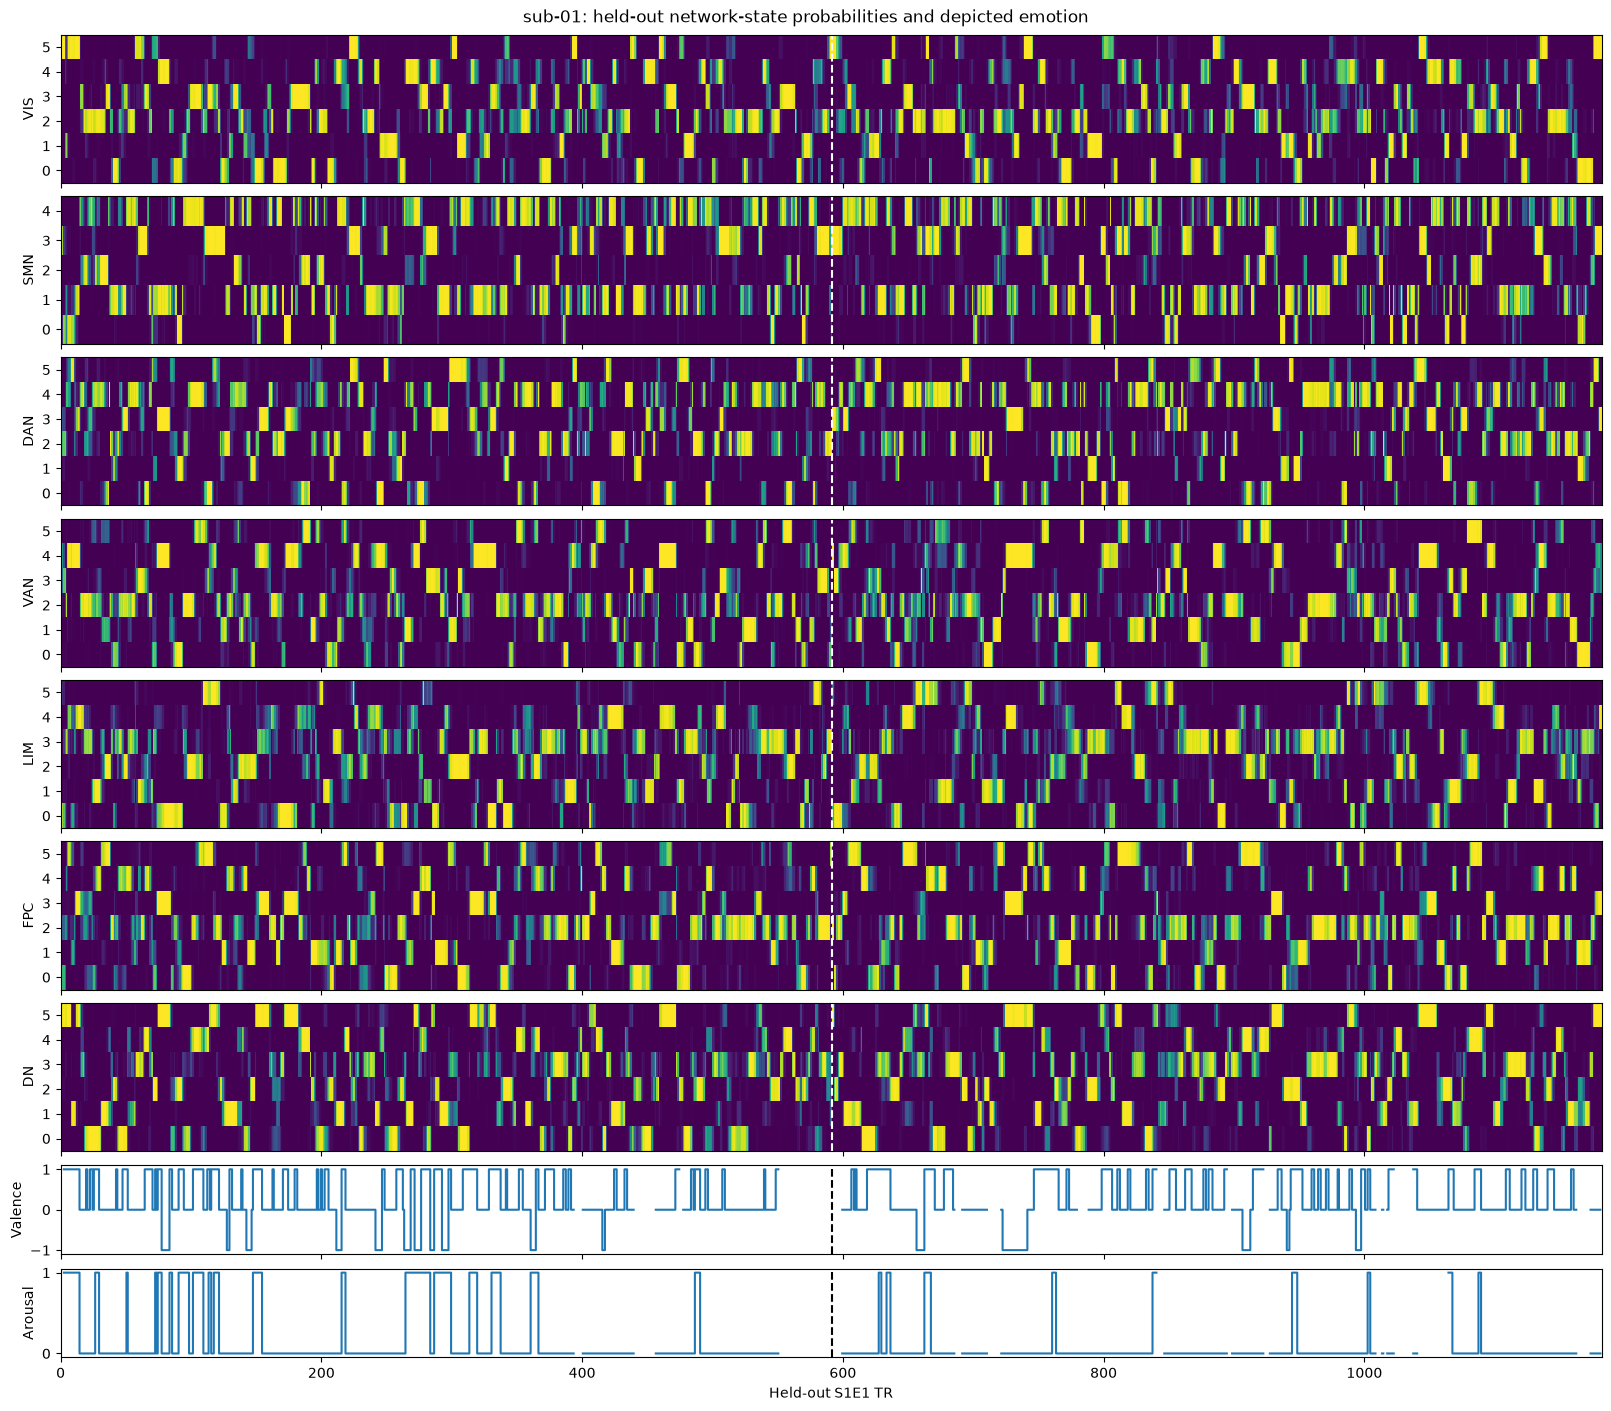

In [9]:
fig, axes = plt.subplots(
    len(NETWORKS) + 2, 1, figsize=(16, 14), sharex=True,
    gridspec_kw={'height_ratios': [1] * len(NETWORKS) + [0.6, 0.6]},
    constrained_layout=True,
)
for axis, network in zip(axes, NETWORKS):
    gamma = aligned[network]['gamma']
    axis.imshow(
        gamma.T, aspect='auto', origin='lower', interpolation='nearest',
        extent=[0, len(gamma), -0.5, gamma.shape[1] - 0.5], vmin=0, vmax=1,
    )
    axis.set_ylabel(network)
    axis.set_yticks(range(gamma.shape[1]))
axes[-2].step(np.arange(len(primary_labels)), primary_labels['valence'], where='mid')
axes[-2].set_ylabel('Valence')
axes[-2].set_yticks([-1, 0, 1])
axes[-1].step(np.arange(len(primary_labels)), primary_labels['arousal'], where='mid')
axes[-1].set_ylabel('Arousal')
axes[-1].set_yticks([0, 1])
axes[-1].set_xlabel('Held-out S1E1 TR')
for axis in axes:
    axis.axvline(boundary, color='white' if axis in axes[:-2] else 'black', linestyle='--')
fig.suptitle('sub-01: held-out network-state probabilities and depicted emotion')
fig.savefig(FIGURE_ROOT / 'network_state_timeline.png', dpi=180)
plt.show()

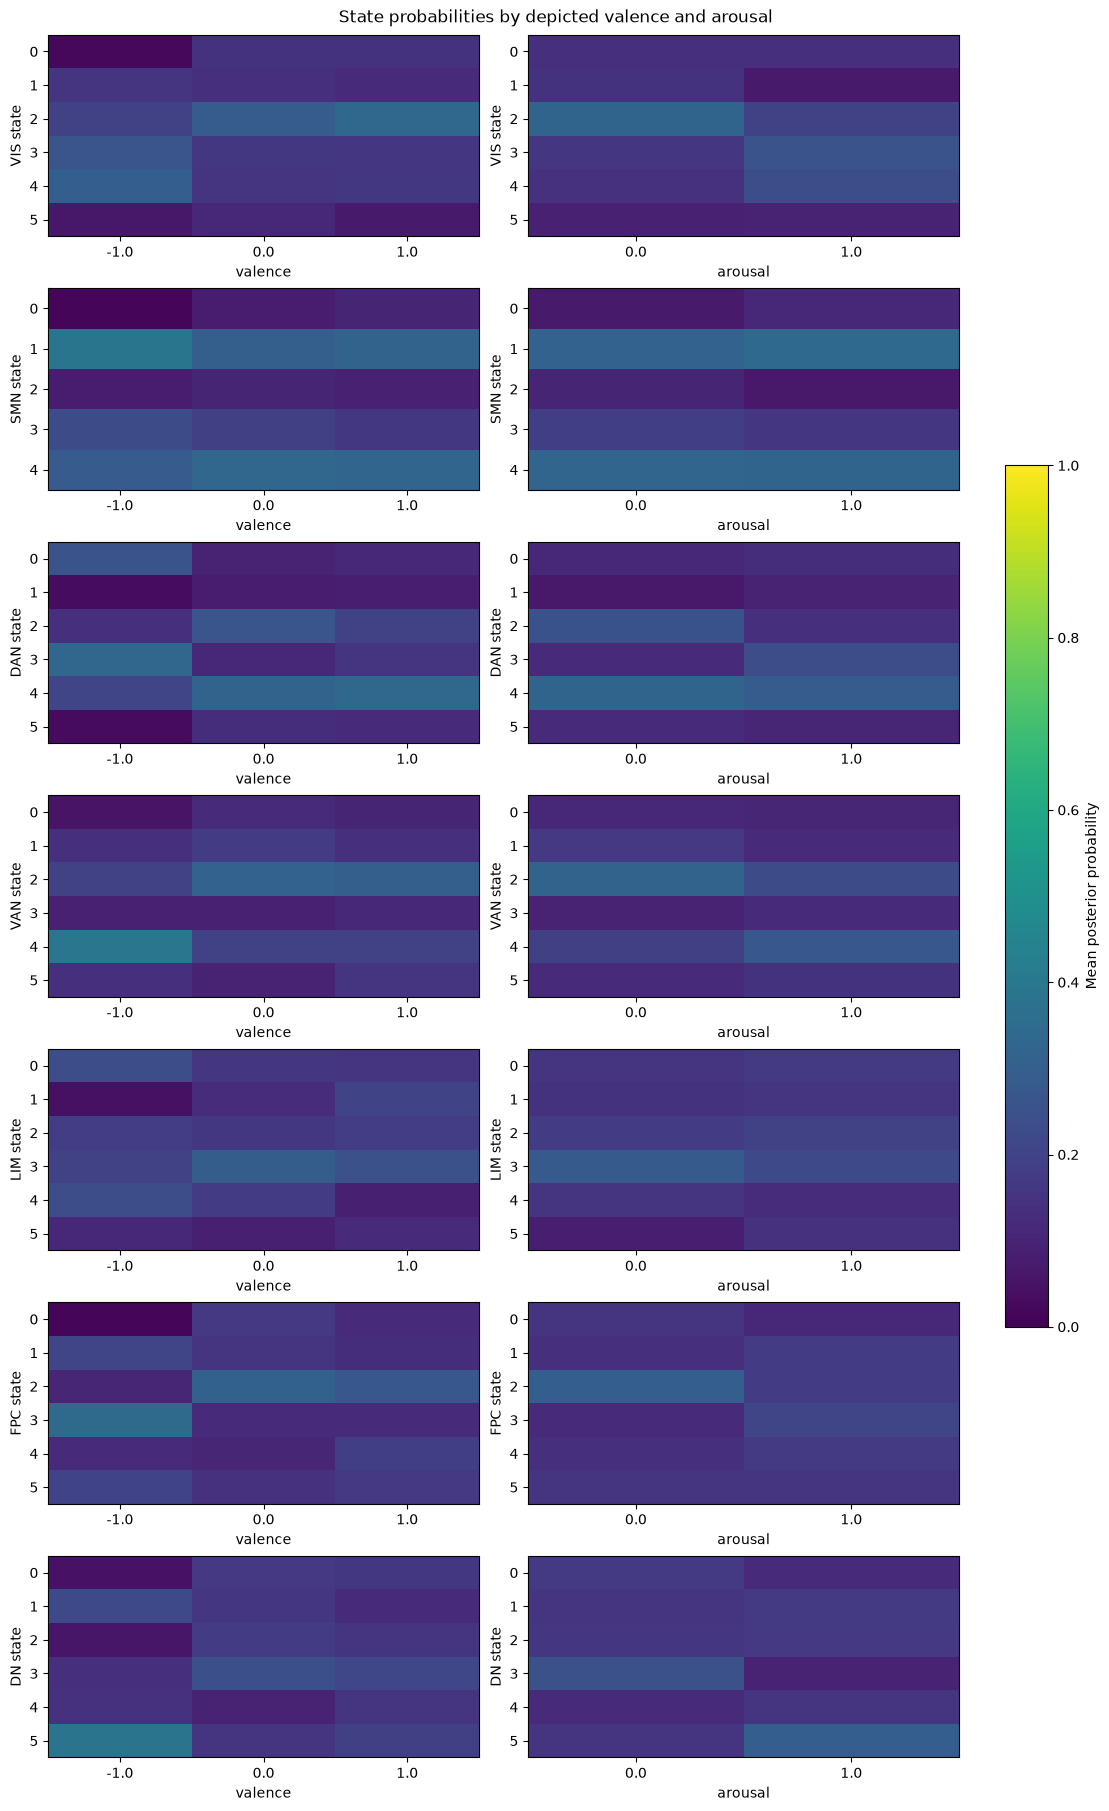

In [10]:
fig, axes = plt.subplots(len(NETWORKS), 2, figsize=(11, 18), constrained_layout=True)
for row, network in enumerate(NETWORKS):
    for column, (label, values) in enumerate((
        ('valence', [-1.0, 0.0, 1.0]), ('arousal', [0.0, 1.0]),
    )):
        subset = state_label_table.query('network == @network and label == @label')
        matrix = subset.pivot(
            index='state', columns='label_value', values='mean_posterior'
        ).reindex(columns=values)
        image = axes[row, column].imshow(matrix, aspect='auto', vmin=0, vmax=1)
        axes[row, column].set_ylabel(f'{network} state')
        axes[row, column].set_xticks(range(len(values)), values)
        axes[row, column].set_xlabel(label)
fig.colorbar(image, ax=axes, label='Mean posterior probability', shrink=0.5)
fig.suptitle('State probabilities by depicted valence and arousal')
fig.savefig(FIGURE_ROOT / 'state_label_heatmaps.png', dpi=180)
plt.show()

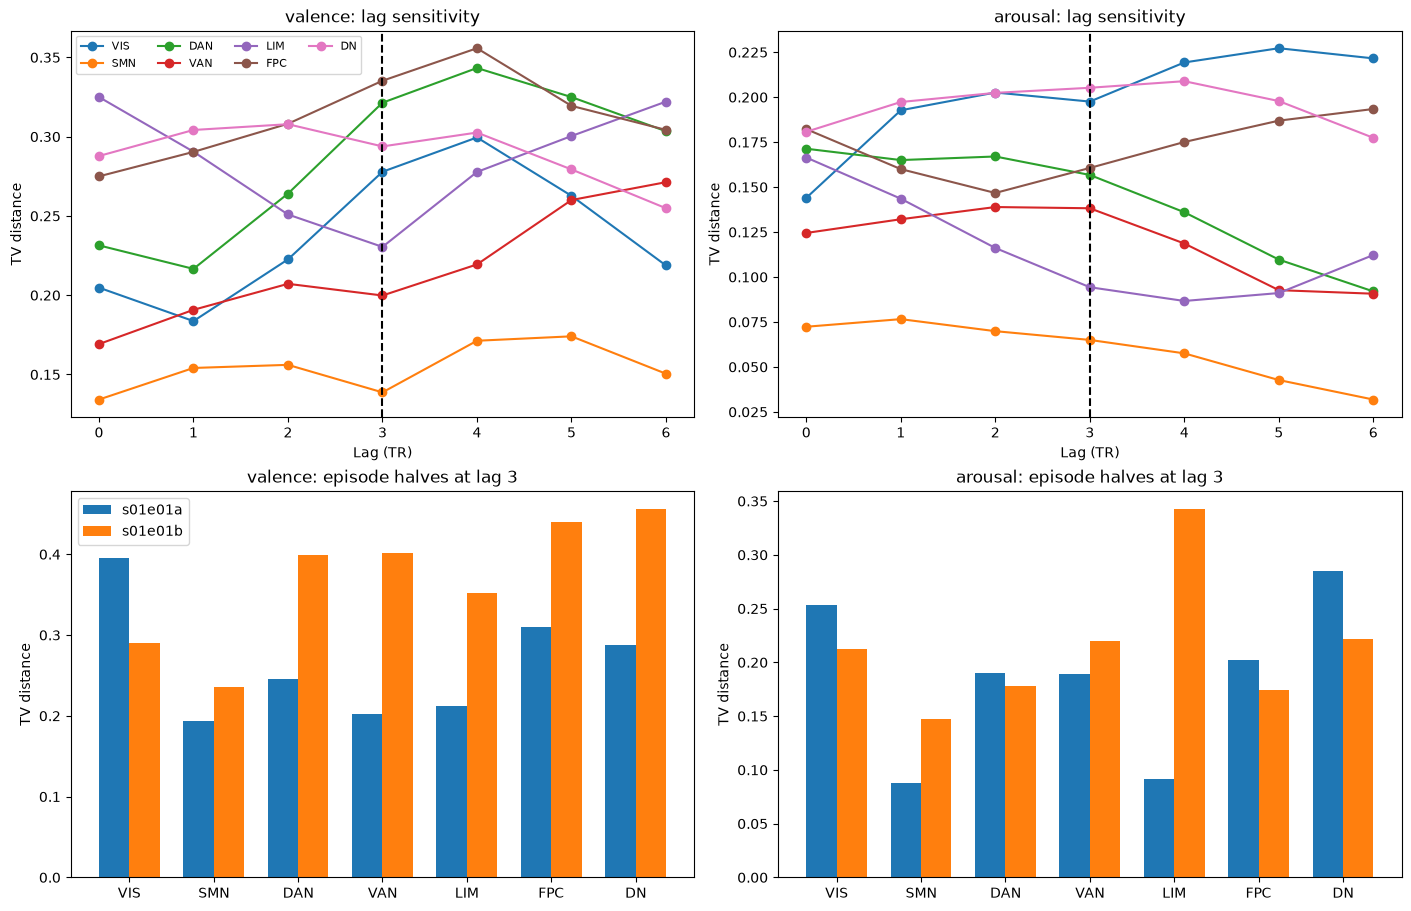

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
for column, label in enumerate(('valence', 'arousal')):
    lag_data = association_table.query("segment == 'all' and label == @label")
    for network in NETWORKS:
        group = lag_data.loc[lag_data['network'].eq(network)].sort_values('lag_tr')
        axes[0, column].plot(
            group['lag_tr'], group['total_variation'], marker='o', label=network,
        )
    axes[0, column].axvline(PRIMARY_LAG, color='black', linestyle='--')
    axes[0, column].set(title=f'{label}: lag sensitivity', xlabel='Lag (TR)', ylabel='TV distance')

    half_data = association_table.query(
        "segment != 'all' and label == @label and lag_tr == @PRIMARY_LAG"
    )
    x = np.arange(len(NETWORKS))
    for offset, segment in zip((-0.18, 0.18), ('s01e01a', 's01e01b')):
        values = (
            half_data.loc[half_data['segment'].eq(segment)]
            .set_index('network').reindex(NETWORKS)['total_variation']
        )
        axes[1, column].bar(x + offset, values, width=0.36, label=segment)
    axes[1, column].set(
        title=f'{label}: episode halves at lag {PRIMARY_LAG}',
        ylabel='TV distance', xticks=x, xticklabels=NETWORKS,
    )
axes[0, 0].legend(ncol=4, fontsize=8)
axes[1, 0].legend()
fig.savefig(FIGURE_ROOT / 'association_robustness.png', dpi=180)
plt.show()

## Project BOLD and HMM-implied emotion contrasts onto the cortex

Direct maps show mean held-out parcel BOLD differences. HMM-implied maps back-project each network's state means through PCA and scaling, then weight those parcel patterns by the signed state-posterior contrast. Both are descriptive parcel-level maps.

In [ ]:
with h5py.File(FMRI_PATH, 'r') as handle:
    target_bold = np.concatenate([
        handle[discovered[segment]][:len(labels_by_segment[segment])]
        for segment in TARGET_SEGMENTS
    ])

brain_contrasts = {}
for label, (first, second) in contrasts.items():
    label_values = primary_labels[label].to_numpy()
    brain_contrasts[f'direct_bold_{label}'] = condition_mean_difference(
        target_bold, label_values, first, second
    )
    hmm_contrast = np.zeros(1000)
    for network in NETWORKS:
        artifact = artifacts[network]
        state_parcel_means = artifact['scaler'].inverse_transform(
            artifact['pca'].inverse_transform(artifact['model'].means_)
        )
        hmm_contrast[parcel_indices[network]] = posterior_weighted_parcel_contrast(
            state_parcel_means, aligned[network]['gamma'],
            label_values, first, second,
        )
    brain_contrasts[f'hmm_implied_{label}'] = hmm_contrast

if any(values.shape != (1000,) or not np.isfinite(values).all()
       for values in brain_contrasts.values()):
    raise ValueError('Brain contrasts must contain 1,000 finite parcel values')

network_by_parcel = np.empty(1000, dtype=object)
for network, indices in parcel_indices.items():
    network_by_parcel[indices] = network
brain_contrast_table = pd.DataFrame({
    'parcel_index': np.arange(1000), 'network': network_by_parcel,
    **brain_contrasts,
})
brain_contrast_table.to_csv(RESULT_ROOT / 'brain_contrast_maps.csv', index=False)
brain_contrast_table.describe()

In [ ]:
atlas = datasets.fetch_atlas_schaefer_2018(
    n_rois=1000, yeo_networks=7, resolution_mm=2,
    data_dir=str(PROJECT_ROOT / 'data/cache'),
)
atlas_img = image.load_img(atlas.maps)
atlas_labels = np.asarray(atlas_img.dataobj, dtype=int)
brain_images = {
    name: image.new_img_like(
        atlas_img, parcel_values_to_volume(values, atlas_labels)
    )
    for name, values in brain_contrasts.items()
}
titles = {
    'direct_bold_valence': 'Direct BOLD: positive minus negative valence',
    'direct_bold_arousal': 'Direct BOLD: high minus low arousal',
    'hmm_implied_valence': 'HMM-implied: positive minus negative valence',
    'hmm_implied_arousal': 'HMM-implied: high minus low arousal',
}
output_names = {
    'direct_bold_valence': 'direct_bold_valence.png',
    'direct_bold_arousal': 'direct_bold_arousal.png',
    'hmm_implied_valence': 'hmm_implied_valence.png',
    'hmm_implied_arousal': 'hmm_implied_arousal.png',
}
for name, stat_map in brain_images.items():
    limit = float(np.abs(brain_contrasts[name]).max())
    output_path = FIGURE_ROOT / output_names[name]
    figure, _ = plotting.plot_img_on_surf(
        stat_map, surf_mesh='fsaverage5',
        hemispheres=['left', 'right'], views=['lateral', 'medial'],
        cmap='RdBu_r', colorbar=True, symmetric_cbar=True,
        vmin=-limit, vmax=limit, cbar_tick_format='%.2f',
        title=titles[name],
    )
    figure.set_size_inches(9, 8)
    figure.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close(figure)
    print(output_path)